In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Change this string to explore a different compare_model_predictions.py output.
CSV_FILE = "../sequence_to_svm_minimal/data/proteomes/candidates/generated/model_comparison_latest.csv"
CSV_PATH = Path(CSV_FILE).expanduser().resolve()

# Optional location for derived outputs, plots, or exports.
OUTPUT_DIR = CSV_PATH.parent

# If you want nicer default styling:
plt.style.use("seaborn-v0_8-whitegrid")



In [2]:
if not CSV_PATH.is_file():
    raise FileNotFoundError(f"Comparison CSV not found: {CSV_PATH}")

df = pd.read_csv(CSV_PATH)

score_cols = [c for c in df.columns if c.endswith("_score_z")]
models = [c[: -len("_score_z")] for c in score_cols]

print(f"Loaded: {CSV_PATH}")
print(f"Rows: {len(df):,}")
print(f"Models with z-scores: {models}")


Loaded: C:\Users\bioin\Documents\Peptide-Anti-microbial-Properties-Prediction\sequence_to_svm_minimal\data\proteomes\candidates\generated\model_comparison_latest.csv
Rows: 400,000
Models with z-scores: ['SVM']


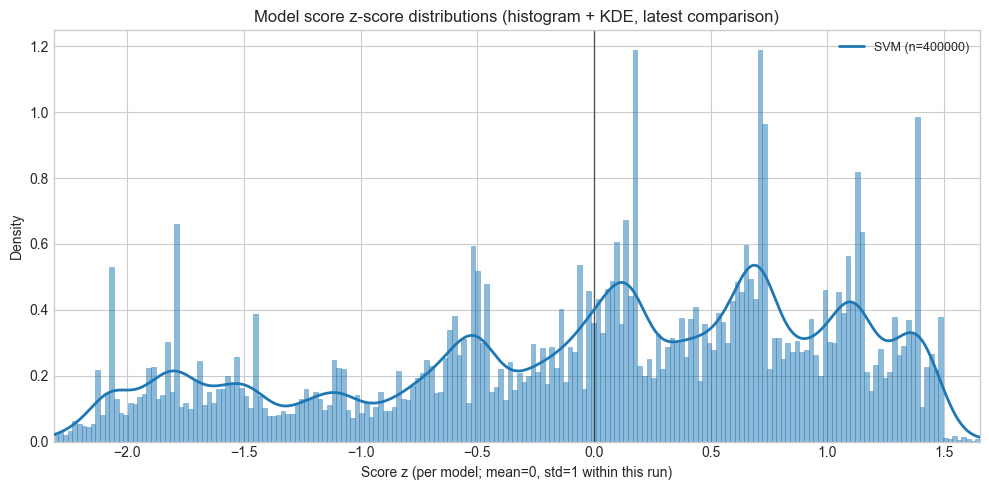

In [3]:
# Z-score distributions: histogram + KDE (smooth curve on top, shared bins / x grid)
from scipy.stats import gaussian_kde

vals = []
for c in score_cols:
    v = pd.to_numeric(df[c], errors="coerce").dropna().to_numpy(dtype=float)
    if v.size:
        vals.append(v)

if not vals:
    raise ValueError("No finite z-scores found in the CSV.")

all_v = np.concatenate(vals)
lo = float(np.nanpercentile(all_v, 1))
hi = float(np.nanpercentile(all_v, 99))
pad = 0.05 * (hi - lo) if hi > lo else 1.0
xlim = (lo - pad, hi + pad)

n_bins = 200
bins = np.linspace(xlim[0], xlim[1], n_bins + 1)

curve_entries = []
for model, col in zip(models, score_cols):
    v = pd.to_numeric(df[col], errors="coerce").dropna().to_numpy(dtype=float)
    if v.size >= 5:
        curve_entries.append((model, v))

if not curve_entries:
    raise ValueError("No model with >=5 finite z-scores.")

n_curves = len(curve_entries)
colors = plt.cm.tab10(np.linspace(0, 1, max(n_curves, 10)))[:n_curves]
xs = np.linspace(xlim[0], xlim[1], 512)

plt.figure(figsize=(10, 5))
for i, (model, v) in enumerate(curve_entries):
    c = colors[i]
    plt.hist(
        v,
        bins=bins,
        density=True,
        histtype="bar",
        linewidth=0.5,
        edgecolor=c,
        facecolor=c,
        alpha=0.5,
        zorder=1,
    )

for i, (model, v) in enumerate(curve_entries):
    c = colors[i]
    try:
        d = gaussian_kde(v)(xs)
    except np.linalg.LinAlgError:
        continue
    plt.plot(
        xs,
        d,
        color=c,
        linewidth=2,
        label=f"{model} (n={len(v)})",
        zorder=3,
    )

plt.axvline(0.0, color="black", linewidth=1, alpha=0.6, zorder=2)
plt.xlim(*xlim)
plt.xlabel("Score z (per model; mean=0, std=1 within this run)")
plt.ylabel("Density")
plt.title("Model score z-score distributions (histogram + KDE, latest comparison)")
plt.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()


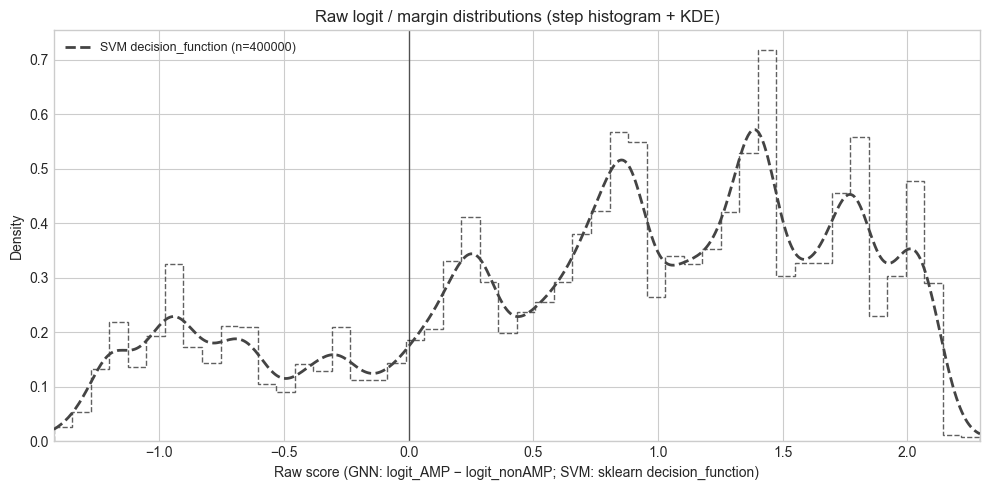

In [4]:
# Raw classifier scores: step histogram + KDE (GNN logit margin; SVM = decision_function)
margin_cols = sorted(c for c in df.columns if c.endswith("_logit_margin"))
vals_raw = []
for c in margin_cols:
    v = pd.to_numeric(df[c], errors="coerce").dropna().to_numpy(dtype=float)
    if v.size:
        vals_raw.append(v)
if "SVM_distance" in df.columns:
    v = pd.to_numeric(df["SVM_distance"], errors="coerce").dropna().to_numpy(dtype=float)
    if v.size:
        vals_raw.append(v)

if not vals_raw:
    raise ValueError("No finite raw scores found (_logit_margin or SVM_distance).")

all_raw = np.concatenate(vals_raw)
lo_r = float(np.nanpercentile(all_raw, 1))
hi_r = float(np.nanpercentile(all_raw, 99))
pad_r = 0.05 * (hi_r - lo_r) if hi_r > lo_r else 1.0
xlim_raw = (lo_r - pad_r, hi_r + pad_r)

# Histogram + KDE on top (same colors); SVM dashed
from scipy.stats import gaussian_kde

n_bins_raw = 50
bins_raw = np.linspace(xlim_raw[0], xlim_raw[1], n_bins_raw + 1)

gnn_entries = []
for col in margin_cols:
    v = pd.to_numeric(df[col], errors="coerce").dropna().to_numpy(dtype=float)
    if v.size >= 5:
        gnn_entries.append((col.replace("_logit_margin", ""), v))

svm_entry = None
if "SVM_distance" in df.columns:
    v_svm = pd.to_numeric(df["SVM_distance"], errors="coerce").dropna().to_numpy(dtype=float)
    if v_svm.size >= 5:
        svm_entry = ("SVM decision_function", v_svm)

xs_r = np.linspace(xlim_raw[0], xlim_raw[1], 512)
n_gnn = len(gnn_entries)
colors_gnn = plt.cm.tab10(np.linspace(0, 1, max(n_gnn, 10)))[:n_gnn]
svm_color = "#444444"

plt.figure(figsize=(10, 5))
for i, (name, v) in enumerate(gnn_entries):
    c = colors_gnn[i]
    plt.hist(
        v,
        bins=bins_raw,
        density=True,
        histtype="step",
        linewidth=1,
        color=c,
        alpha=0.85,
        zorder=1,
    )

if svm_entry is not None:
    _, v_svm = svm_entry
    plt.hist(
        v_svm,
        bins=bins_raw,
        density=True,
        histtype="step",
        linewidth=1,
        linestyle="--",
        color=svm_color,
        alpha=0.85,
        zorder=1,
    )

for i, (name, v) in enumerate(gnn_entries):
    c = colors_gnn[i]
    try:
        d = gaussian_kde(v)(xs_r)
    except np.linalg.LinAlgError:
        continue
    plt.plot(
        xs_r,
        d,
        color=c,
        linewidth=2,
        label=f"{name} (n={len(v)})",
        zorder=3,
    )

if svm_entry is not None:
    name, v_svm = svm_entry
    try:
        d_svm = gaussian_kde(v_svm)(xs_r)
    except np.linalg.LinAlgError:
        d_svm = None
    if d_svm is not None:
        plt.plot(
            xs_r,
            d_svm,
            color=svm_color,
            linewidth=2,
            linestyle="--",
            label=f"{name} (n={len(v_svm)})",
            zorder=3,
        )

plt.axvline(0.0, color="black", linewidth=1, alpha=0.6, zorder=2)
plt.xlim(*xlim_raw)
plt.xlabel("Raw score (GNN: logit_AMP − logit_nonAMP; SVM: sklearn decision_function)")
plt.ylabel("Density")
plt.title("Raw logit / margin distributions (step histogram + KDE)")
plt.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()
